# Лабораторная 3

## Задание

### 1. Возьмите один простой набор данных (MNIST, FMNIST, CIFAR-10 и т.д.). Обучите на нём простую модель нейронной сети (не CNN!!!) с применением методов регуляризации и с функцией активации ReLU. Архитектуру задаете сами. Постройте график значения функции потерь от количества эпох, а также график метрик качества от количества эпох

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import copy
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

In [2]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{device}")

cuda


In [3]:
batch_size= 64
lr= 0.001
weight_decay= 1e-4
epochs= 30
seed= 42

In [4]:
transform= transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

val_size = int(0.2* len(full_dataset))
train_size= len(full_dataset) - val_size

train_data, val_data = random_split(full_dataset,[train_size, val_size], generator=torch.Generator().manual_seed(seed))

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [5]:
class MyModel_1(nn.Module):
    def __init__(self, num_classes):
        super(MyModel_1, self).__init__()
        self.flatten = nn.Flatten()

        self.fc_layers = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

In [6]:
model = MyModel_1(num_classes=len(full_dataset.classes)).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Всего параметров: 537,354


In [7]:
history_1 = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
weights = copy.deepcopy(model.state_dict())
best_loss = 1000.0
cnt = 0
cnt2 = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(all_train_labels, all_train_preds)
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    model.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(all_val_labels, all_val_preds)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    scheduler.step(avg_val_loss)

    history_1['train_loss'].append(avg_train_loss)
    history_1['val_loss'].append(avg_val_loss)
    history_1['train_acc'].append(avg_train_acc)
    history_1['val_acc'].append(avg_val_acc)
    history_1['train_f1'].append(epoch_train_f1)
    history_1['val_f1'].append(epoch_val_f1)

    if (epoch+1) % 5 ==0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} F1: {epoch_train_f1:.3f} | Val Loss: {avg_val_loss:.3f} F1: {epoch_val_f1:.3f}")

    if epoch_val_f1 > best_val_f1 and (avg_val_loss < best_loss or avg_val_loss - best_loss < 0.01):
        best_val_f1 = epoch_val_f1
        best_loss = avg_val_loss
        weights = copy.deepcopy(model.state_dict())
        cnt2 = 0

    if best_val_f1 - epoch_val_f1 < 0.2:
        cnt2 += 1
    if cnt2 == 15:
        print("F1 на валидации не улучшается 15 эпох")
        break

    if epoch_train_f1 - epoch_val_f1 > 0.15:
        cnt += 1
    else:
        cnt = 0
    if cnt == 5:
        print(f"Переобучение Разрыв F1: {(epoch_train_f1 - epoch_val_f1)*100:.2f}%")
        break

model.load_state_dict(weights)
model.eval()
all_test_preds, all_test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(all_test_labels, all_test_preds)
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')

print(f"Лучшая F1 на валидации: {best_val_f1:.3f}")
print(f"Итоговые оценки | Acc: {final_test_acc:.3f} | F1: {final_test_f1:.3f}")

Epoch 5/30 | Train Loss: 0.769 F1: 0.887 | Val Loss: 0.759 F1: 0.882
Epoch 10/30 | Train Loss: 0.725 F1: 0.909 | Val Loss: 0.734 F1: 0.895
Epoch 15/30 | Train Loss: 0.697 F1: 0.923 | Val Loss: 0.728 F1: 0.896
Epoch 20/30 | Train Loss: 0.676 F1: 0.933 | Val Loss: 0.721 F1: 0.901
Epoch 25/30 | Train Loss: 0.640 F1: 0.951 | Val Loss: 0.715 F1: 0.906
Epoch 30/30 | Train Loss: 0.621 F1: 0.961 | Val Loss: 0.711 F1: 0.907
Лучшая F1 на валидации: 0.909
Итоговые оценки | Acc: 0.904 | F1: 0.904


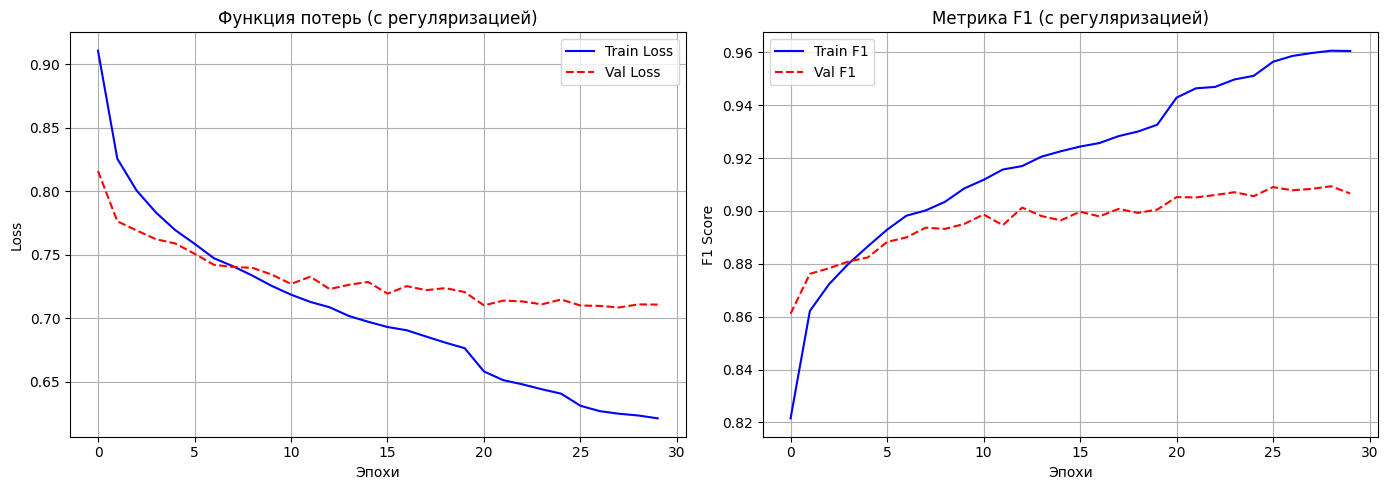

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1['train_loss'], label='Train Loss', color='blue')
plt.plot(history_1['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('Функция потерь (с регуляризацией)')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1['train_f1'], label='Train F1', color='blue')
plt.plot(history_1['val_f1'], label='Val F1', color='red', linestyle='--')
plt.title('Метрика F1 (с регуляризацией)')
plt.xlabel('Эпохи')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### 2. Уберите из архитектуры регуляризацию. Что стало с результатом? Постройте графики и сравните с оригинальной моделью

In [9]:
class MyModel_2(nn.Module):
    def __init__(self, num_classes):
        super(MyModel_2, self).__init__()
        self.flatten = nn.Flatten()

        self.fc_layers = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

In [10]:
model2 = MyModel_2(num_classes=len(full_dataset.classes)).to(device)

total_params = sum(p.numel() for p in model2.parameters())
print(f"Всего параметров: {total_params:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model2.parameters(), lr=lr, weight_decay=0)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Всего параметров: 537,354


In [11]:
history_2 = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
weights = copy.deepcopy(model2.state_dict())
best_loss = 1000.0
cnt = 0
cnt2 = 0

for epoch in range(epochs):
    model2.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model2.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(all_train_labels, all_train_preds)
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    model2.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(all_val_labels, all_val_preds)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    scheduler.step(avg_val_loss)

    history_2['train_loss'].append(avg_train_loss)
    history_2['val_loss'].append(avg_val_loss)
    history_2['train_acc'].append(avg_train_acc)
    history_2['val_acc'].append(avg_val_acc)
    history_2['train_f1'].append(epoch_train_f1)
    history_2['val_f1'].append(epoch_val_f1)

    if (epoch+1) % 5 ==0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} F1: {epoch_train_f1:.3f} | Val Loss: {avg_val_loss:.3f} F1: {epoch_val_f1:.3f}")

    if epoch_val_f1 > best_val_f1 and (avg_val_loss < best_loss or avg_val_loss - best_loss < 0.01):
        best_val_f1 = epoch_val_f1
        best_loss = avg_val_loss
        weights = copy.deepcopy(model2.state_dict())
        cnt2 = 0

model2.load_state_dict(weights)
model2.eval()
all_test_preds, all_test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(all_test_labels, all_test_preds)
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')

print(f"Лучшая F1 на валидации: {best_val_f1:.3f}")
print(f"Итоговые оценки | Acc: {final_test_acc:.3f} | F1: {final_test_f1:.3f}")

Epoch 5/30 | Train Loss: 0.709 F1: 0.909 | Val Loss: 0.740 F1: 0.889
Epoch 10/30 | Train Loss: 0.649 F1: 0.938 | Val Loss: 0.730 F1: 0.897
Epoch 15/30 | Train Loss: 0.590 F1: 0.969 | Val Loss: 0.721 F1: 0.907
Epoch 20/30 | Train Loss: 0.555 F1: 0.986 | Val Loss: 0.729 F1: 0.904
Epoch 25/30 | Train Loss: 0.541 F1: 0.992 | Val Loss: 0.728 F1: 0.907
Epoch 30/30 | Train Loss: 0.535 F1: 0.995 | Val Loss: 0.732 F1: 0.906
Лучшая F1 на валидации: 0.908
Итоговые оценки | Acc: 0.906 | F1: 0.905


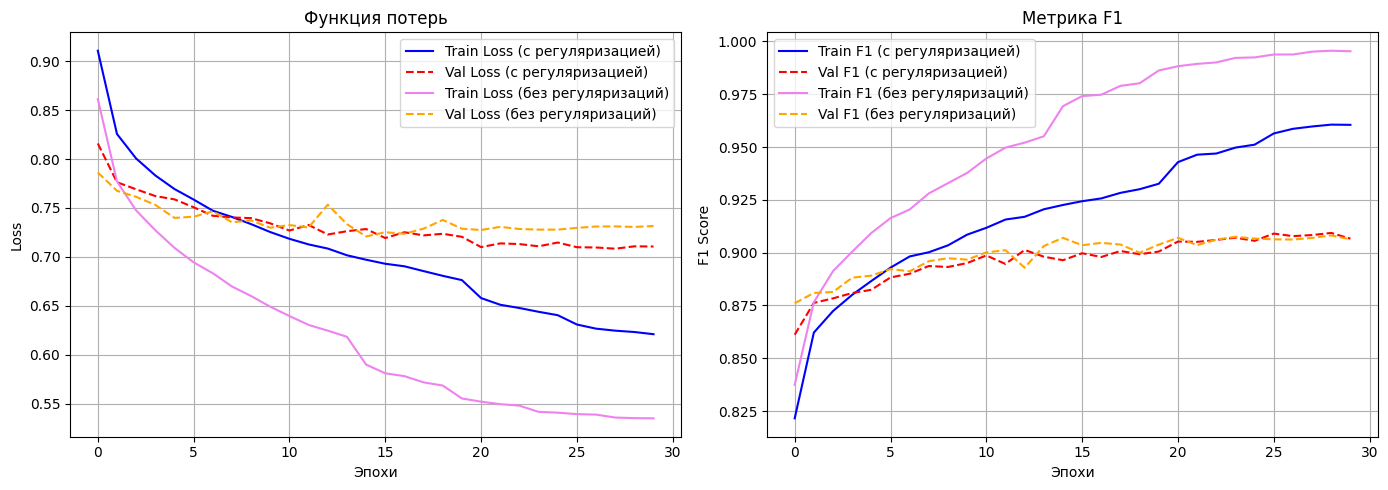

In [12]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1['train_loss'], label='Train Loss (с регуляризацией)', color='blue')
plt.plot(history_1['val_loss'], label='Val Loss (с регуляризацией)', color='red', linestyle='--')
plt.plot(history_2['train_loss'], label='Train Loss (без регуляризаций)', color='violet')
plt.plot(history_2['val_loss'], label='Val Loss (без регуляризаций)', color='orange', linestyle='--')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1['train_f1'], label='Train F1 (с регуляризацией)', color='blue')
plt.plot(history_1['val_f1'], label='Val F1 (с регуляризацией)', color='red', linestyle='--')
plt.plot(history_2['train_f1'], label='Train F1 (без регуляризаций)', color='violet')
plt.plot(history_2['val_f1'], label='Val F1 (без регуляризаций)', color='orange', linestyle='--')
plt.title('Метрика F1')
plt.xlabel('Эпохи')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#### Отказ от регуляризации привел к быстрому переобучению. Модель лишилась способности к обобщению, из-за чего рост метрик на тренировочной выборке стал заучиванием и не привел к улучшению качества классификации на новых данных

### 3. Замените ReLU на сигмоиду. Что стало с результатом? Если он ухудшился, то почему? Постройте графики и сравните с оригинальной моделью

In [13]:
class MyModel_3(nn.Module):
    def __init__(self, num_classes):
        super(MyModel_3, self).__init__()
        self.flatten = nn.Flatten()

        self.fc_layers = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.Sigmoid(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.Sigmoid(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

In [14]:
model3 = MyModel_3(num_classes=len(full_dataset.classes)).to(device)

total_params = sum(p.numel() for p in model3.parameters())
print(f"Всего параметров: {total_params:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model3.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Всего параметров: 537,354


In [15]:
history_3 = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
weights = copy.deepcopy(model3.state_dict())
best_loss = 1000.0
cnt = 0
cnt2 = 0

for epoch in range(epochs):
    model3.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model3(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model3.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(all_train_labels, all_train_preds)
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    model3.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model3(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(all_val_labels, all_val_preds)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    scheduler.step(avg_val_loss)

    history_3['train_loss'].append(avg_train_loss)
    history_3['val_loss'].append(avg_val_loss)
    history_3['train_acc'].append(avg_train_acc)
    history_3['val_acc'].append(avg_val_acc)
    history_3['train_f1'].append(epoch_train_f1)
    history_3['val_f1'].append(epoch_val_f1)

    if (epoch+1) % 5 ==0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} F1: {epoch_train_f1:.3f} | Val Loss: {avg_val_loss:.3f} F1: {epoch_val_f1:.3f}")

    if epoch_val_f1 > best_val_f1 and (avg_val_loss < best_loss or avg_val_loss - best_loss < 0.01):
        best_val_f1 = epoch_val_f1
        best_loss = avg_val_loss
        weights = copy.deepcopy(model3.state_dict())
        cnt2 = 0

    if best_val_f1 - epoch_val_f1 < 0.2:
        cnt2 += 1
    if cnt2 == 15:
        print("F1 на валидации не улучшается 15 эпох")
        break

    if epoch_train_f1 - epoch_val_f1 > 0.15:
        cnt += 1
    else:
        cnt = 0
    if cnt == 5:
        print(f"Переобучение Разрыв F1: {(epoch_train_f1 - epoch_val_f1)*100:.2f}%")
        break

model3.load_state_dict(weights)
model3.eval()
all_test_preds, all_test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model3(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(all_test_labels, all_test_preds)
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')

print(f"Лучшая F1 на валидации: {best_val_f1:.3f}")
print(f"Итоговые оценки | Acc: {final_test_acc:.3f} | F1: {final_test_f1:.3f}")

Epoch 5/30 | Train Loss: 0.859 F1: 0.852 | Val Loss: 0.826 F1: 0.859
Epoch 10/30 | Train Loss: 0.802 F1: 0.876 | Val Loss: 0.790 F1: 0.872
Epoch 15/30 | Train Loss: 0.761 F1: 0.893 | Val Loss: 0.754 F1: 0.887
Epoch 20/30 | Train Loss: 0.732 F1: 0.905 | Val Loss: 0.744 F1: 0.891
Epoch 25/30 | Train Loss: 0.707 F1: 0.918 | Val Loss: 0.744 F1: 0.892
Epoch 30/30 | Train Loss: 0.672 F1: 0.934 | Val Loss: 0.733 F1: 0.898
Лучшая F1 на валидации: 0.898
Итоговые оценки | Acc: 0.894 | F1: 0.894


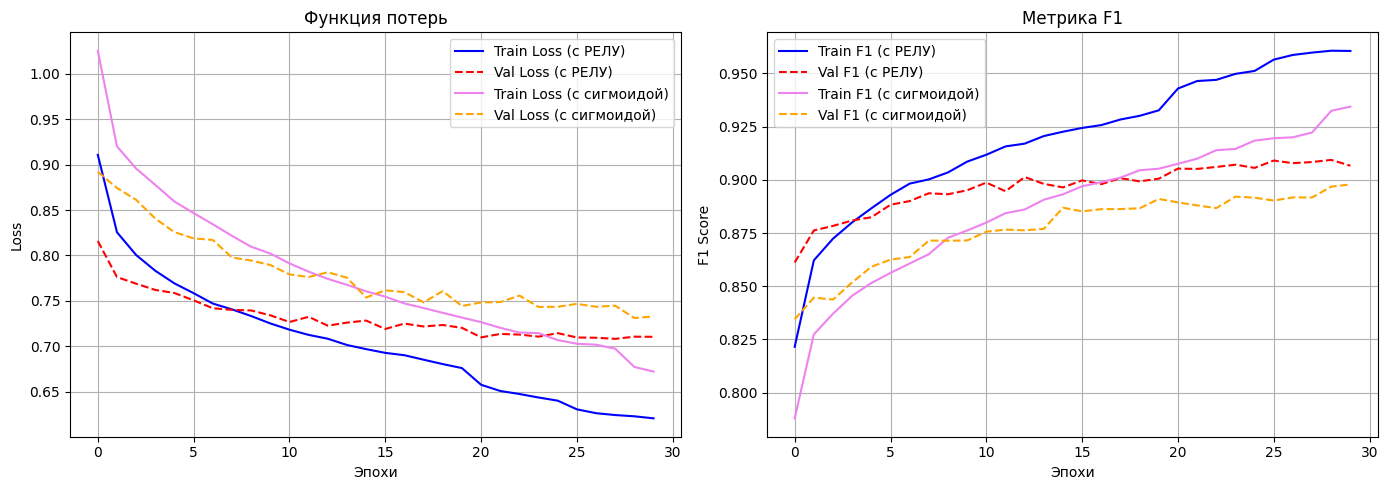

In [16]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1['train_loss'], label='Train Loss (с РЕЛУ)', color='blue')
plt.plot(history_1['val_loss'], label='Val Loss (с РЕЛУ)', color='red', linestyle='--')
plt.plot(history_3['train_loss'], label='Train Loss (с сигмоидой)', color='violet')
plt.plot(history_3['val_loss'], label='Val Loss (с сигмоидой)', color='orange', linestyle='--')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1['train_f1'], label='Train F1 (с РЕЛУ)', color='blue')
plt.plot(history_1['val_f1'], label='Val F1 (с РЕЛУ)', color='red', linestyle='--')
plt.plot(history_3['train_f1'], label='Train F1 (с сигмоидой)', color='violet')
plt.plot(history_3['val_f1'], label='Val F1 (с сигмоидой)', color='orange', linestyle='--')
plt.title('Метрика F1')
plt.xlabel('Эпохи')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#### Замена функции активации на сигмоиду ухудшила качество: функция потерь падает медленнее и застревает на более высоком уровне, а метрика F1 упирается в потолок, проигрывающий оригинальной модели с ReLU. Результат ухудшился из-за проблемы затухающего градиента. Сигмоида жестко сплющивает любые значения в узкий диапазон от 0 до 1, из-за чего её производная никогда не превышает 0.25, соответственно во время обратного распространения ошибки дробные значения перемножаются, градиент затухает и значение ошибки не доходит в начало сети

### 4. Обучите простую CNN на выбранном датасете. Визуализируйте активации на первых слоях сети. Какие закономерности находит модель?

In [17]:
class MyCNN(nn.Module):
    def __init__(self, num_classes):
        super(MyCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

In [18]:
model_cnn = MyCNN(num_classes=len(full_dataset.classes)).to(device)

total_params_cnn = sum(p.numel() for p in model_cnn.parameters())
print(f"Всего параметров: {total_params_cnn:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=lr, weight_decay=weight_decay)
scheduler_cnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='min', factor=0.5, patience=3)

Всего параметров: 207,018


In [19]:
history_4 = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
weights = copy.deepcopy(model_cnn.state_dict())
best_loss = 1000.0
cnt = 0
cnt2 = 0

for epoch in range(epochs):
    model_cnn.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_cnn.parameters(), max_norm=1.0)
        optimizer_cnn.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(all_train_labels, all_train_preds)
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    model_cnn.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cnn(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(all_val_labels, all_val_preds)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    scheduler_cnn.step(avg_val_loss)

    history_4['train_loss'].append(avg_train_loss)
    history_4['val_loss'].append(avg_val_loss)
    history_4['train_acc'].append(avg_train_acc)
    history_4['val_acc'].append(avg_val_acc)
    history_4['train_f1'].append(epoch_train_f1)
    history_4['val_f1'].append(epoch_val_f1)

    if (epoch+1) % 5 ==0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} F1: {epoch_train_f1:.3f} | Val Loss: {avg_val_loss:.3f} F1: {epoch_val_f1:.3f}")

    if epoch_val_f1 > best_val_f1 and (avg_val_loss < best_loss or avg_val_loss - best_loss < 0.01):
        best_val_f1 = epoch_val_f1
        best_loss = avg_val_loss
        weights = copy.deepcopy(model_cnn.state_dict())
        cnt2 = 0

    if best_val_f1 - epoch_val_f1 < 0.2:
        cnt2 += 1
    if cnt2 == 15:
        print("F1 на валидации не улучшается 15 эпох")
        break

    if epoch_train_f1 - epoch_val_f1 > 0.15:
        cnt += 1
    else:
        cnt = 0
    if cnt == 5:
        print(f"Переобучение Разрыв F1: {(epoch_train_f1 - epoch_val_f1)*100:.2f}%")
        break

model_cnn.load_state_dict(weights)
model_cnn.eval()
all_test_preds, all_test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(all_test_labels, all_test_preds)
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')

print(f"Лучшая F1 на валидации: {best_val_f1:.3f}")
print(f"Итоговые оценки | Acc: {final_test_acc:.3f} | F1: {final_test_f1:.3f}")

Epoch 5/30 | Train Loss: 0.727 F1: 0.919 | Val Loss: 0.703 F1: 0.917
Epoch 10/30 | Train Loss: 0.685 F1: 0.941 | Val Loss: 0.703 F1: 0.918
Epoch 15/30 | Train Loss: 0.648 F1: 0.960 | Val Loss: 0.685 F1: 0.926
Epoch 20/30 | Train Loss: 0.628 F1: 0.971 | Val Loss: 0.686 F1: 0.928
Epoch 25/30 | Train Loss: 0.618 F1: 0.978 | Val Loss: 0.688 F1: 0.928
Epoch 30/30 | Train Loss: 0.614 F1: 0.979 | Val Loss: 0.689 F1: 0.928
Лучшая F1 на валидации: 0.929
Итоговые оценки | Acc: 0.919 | F1: 0.919


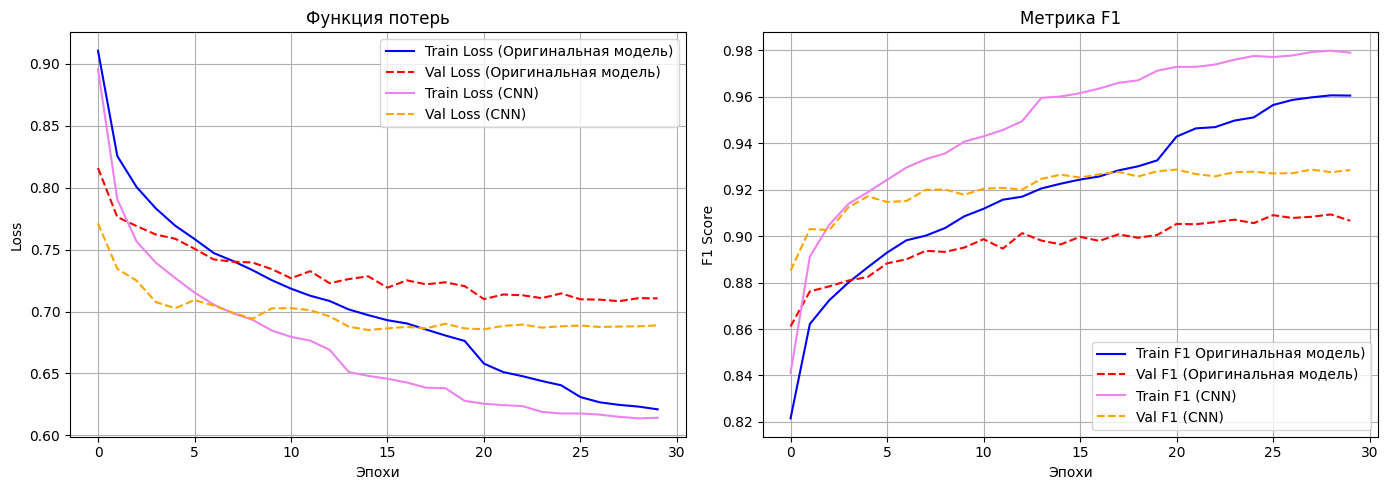

In [20]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1['train_loss'], label='Train Loss (Оригинальная модель)', color='blue')
plt.plot(history_1['val_loss'], label='Val Loss (Оригинальная модель)', color='red', linestyle='--')
plt.plot(history_4['train_loss'], label='Train Loss (CNN)', color='violet')
plt.plot(history_4['val_loss'], label='Val Loss (CNN)', color='orange', linestyle='--')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1['train_f1'], label='Train F1 Оригинальная модель)', color='blue')
plt.plot(history_1['val_f1'], label='Val F1 (Оригинальная модель)', color='red', linestyle='--')
plt.plot(history_4['train_f1'], label='Train F1 (CNN)', color='violet')
plt.plot(history_4['val_f1'], label='Val F1 (CNN)', color='orange', linestyle='--')
plt.title('Метрика F1')
plt.xlabel('Эпохи')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

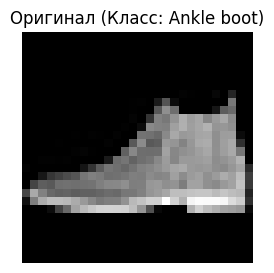

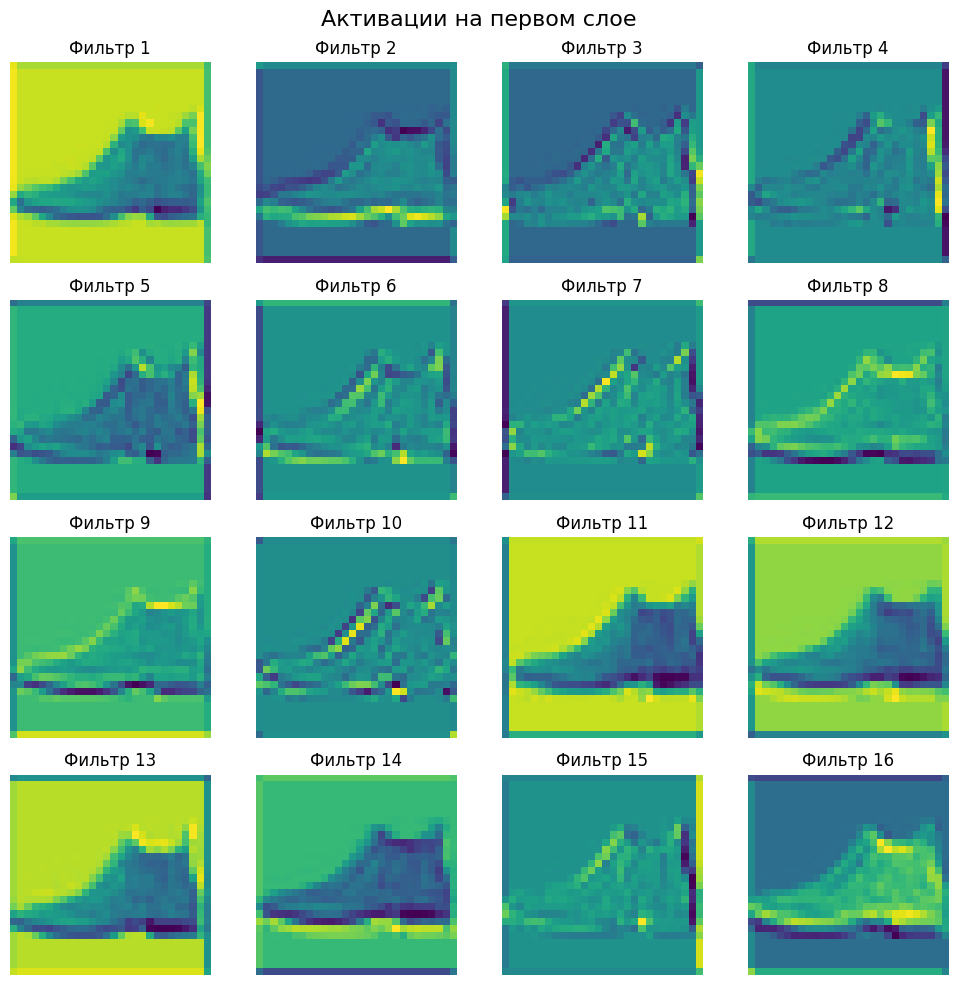

In [26]:
it = iter(test_loader)
images, labels = next(it)

img = images[0]
label = labels[0].item()

first_l = model_cnn.conv_layers[0]

with torch.no_grad():
    layers = first_l(img.unsqueeze(0).to(device))

layers = layers.squeeze(0).cpu().numpy()
orig_img = img.squeeze(0).numpy()
class_names = full_dataset.classes

plt.figure(figsize=(3, 3))
plt.imshow(orig_img, cmap='gray')
plt.title(f'Оригинал (Класс: {class_names[label]})')
plt.axis('off')
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Активации на первом слое', fontsize=16)

for i, ax in enumerate(axes.flat):
    ax.imshow(layers[i], cmap='viridis')
    ax.set_title(f'Фильтр {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Как видно из визуализации, первый слой CNN работает как набор низкоуровневых фильтров, аналогичных оператору Собеля. Модель в процессе обучения научилась разбивать оригинальное изображение на набор геометрических структур. На графиках четко выделяются детекторы контуров: например, фильтр 2 реагирует на нижнюю границу, фильтр 5 работает как детектор вертикальных линий, а фильтр 8 выделяет верхние контуры объекта